# Ekstraksi Fitur, Pelatihan, & Evaluasi Model (FastText + SVM)

Notebook ini mendokumentasikan tahapan inti pemodelan yang memenuhi standar baku pelaporan akademis. Pada tahap ini, data yang sudah bersih dan teraugmentasi akan diproses untuk melatih mesin klasifikasi cerdas.

Tahapan eksplisit yang dilakukan secara berurutan meliputi:
1. **Feature Extraction (Word Embedding FastText)**: Mengubah teks murni menjadi representasi vektor numerik (array 300 dimensi) menggunakan model pre-trained `cc.id.300.bin`. Mesin (SVM) hanya mengerti representasi matematis angka, bukan huruf abjad.
2. **Pembagian Data (Train-Test Split)**: Membagi dataset menjadi dua bagian: Data Latih (80%) untuk mengajari model, dan Data Uji (20%) untuk menguji kecerdasan model pada data yang belum pernah ia lihat sebelumnya.
3. **Hyperparameter Tuning (K-Fold Cross Validation)**: Menggunakan algoritma `GridSearchCV` dengan 5-Fold Cross Validation untuk melatih ratusan kombinasi parameter SVM secara otomatis. Proses ini mencari nilai hiperparameter `C` dan `Kernel` yang paling optimal untuk mencegah *Overfitting* (model terlalu menghafal) atau *Underfitting* (model terlalu bodoh).
4. **Pelatihan Model Terbaik (Best Estimator)**: Setelah parameter terbaik ditemukan, model SVM akhir dilatih menggunakan seluruh Data Latih.
5. **Evaluasi Akademik (Model Testing)**: Melakukan prediksi pada Data Uji dan mengevaluasi kinerja model menggunakan metrik standar (*Precision, Recall, F1-Score, dan Accuracy*), serta memvisualisasikannya melalui *Heatmap Confusion Matrix* untuk melihat dengan jelas tebakan yang benar dan salah.

In [1]:
import pandas as pd
import numpy as np
import fasttext
import pickle
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Konfigurasi Visualisasi Standar Jurnal
sns.set_theme(style="white")
plt.rcParams['figure.figsize'] = (10, 8)

## Membaca Dataset & Pembersihan Teks Akhir

In [2]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text.strip()

print("[LOG] Membaca dataset_labeled.csv...")
df = pd.read_csv('dataset_labeled.csv')
df = df.dropna(subset=['text', 'intent'])

df['clean_text'] = df['text'].apply(clean_text)
df = df[df['clean_text'].str.strip() != '']

print(f"[LOG] Total dataset siap latih: {len(df)} baris.")
display(df.head())

[LOG] Membaca dataset_labeled.csv...
[LOG] Total dataset siap latih: 455 baris.


,text,intent,source,clean_text
0,Iya.,setuju,real,iya
1,Udah yaa bg,setuju,real,udah yaa bg
2,Ok malam mngkn sy ksna ambil,batal,real,ok malam mngkn sy ksna ambil
3,ini saya yang kemarin malam datang yang masala...,batal,real,ini saya yang kemarin malam datang yang masala...
4,"Okee bang, bentar lg ambil",batal,real,okee bang bentar lg ambil


## Ekstraksi Fitur FastText (Word Embeddings)

In [3]:
print("[LOG] Memuat FastText pre-trained model (cc.id.300.bin)...")
if not os.path.exists('cc.id.300.bin'):
    raise FileNotFoundError("cc.id.300.bin tidak ditemukan!")
    
ft_model = fasttext.load_model('cc.id.300.bin')
print("[LOG] FastText berhasil dimuat!")

def get_sentence_vector(text, ft_model):
    words = text.split()
    if not words:
        return np.zeros(ft_model.get_dimension())
    word_vectors = [ft_model.get_word_vector(w) for w in words]
    return np.mean(word_vectors, axis=0)

X = np.array([get_sentence_vector(t, ft_model) for t in df['clean_text']])
y = df['intent'].values

# Tampilkan Cuplikan Ekstraksi Fitur untuk Lampiran Skripsi
df_features = pd.DataFrame(X[:, :5], columns=['Dim_1', 'Dim_2', 'Dim_3', 'Dim_4', 'Dim_5'])
df_features.insert(0, 'intent', y)
df_features.insert(0, 'text', df['clean_text'])
print("\n[TABEL] Cuplikan Vektor Fitur (5 dari 300 dimensi):")
display(df_features.head())

[LOG] Memuat FastText pre-trained model (cc.id.300.bin)...
[LOG] FastText berhasil dimuat!

[TABEL] Cuplikan Vektor Fitur (5 dari 300 dimensi):


,text,intent,Dim_1,Dim_2,Dim_3,Dim_4,Dim_5
0,iya,setuju,0.115416,-0.123420,0.162999,0.252967,0.011302
1,udah yaa bg,setuju,0.097643,-0.049527,-0.006435,0.042647,-0.074569
2,ok malam mngkn sy ksna ambil,batal,0.079368,0.044853,-0.045454,0.075080,-0.041172
3,ini saya yang kemarin malam datang yang masala...,batal,0.013369,-0.005170,0.013596,0.109122,0.021966
4,okee bang bentar lg ambil,batal,0.044146,0.017204,-0.011931,0.054190,0.015221


## 4.3 Pembagian Data (Train 80% : Test 20%)
Membagi data pengujian secara proporsional menggunakan metode *Stratified Sampling*.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"[LOG] Total Data Pembelajaran (Train): {len(X_train)} sampel")
print(f"[LOG] Total Data Pengujian (Test): {len(X_test)} sampel")

[LOG] Total Data Pembelajaran (Train): 364 sampel
[LOG] Total Data Pengujian (Test): 91 sampel


## Hyperparameter Tuning dengan GridSearchCV (5-Fold CV)
Menguji beberapa kombinasi nilai penalti `C` dan `kernel` (Linear vs RBF) untuk menemukan akurasi tertinggi.

In [5]:
print("[LOG] Memulai proses Hyperparameter Tuning (GridSearchCV)...")
print("[LOG] Mencari kombinasi parameter terbaik dari: C=[0.1, 1, 10], kernel=['linear', 'rbf']")

# Parameter Grid yang akan diuji
param_grid = {
    'C': [1, 10, 50, 100],
    'kernel': ['linear', 'rbf'],
    'class_weight': ['balanced']
}

# 5-Fold Cross Validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid,
    cv=cv_strategy,
    scoring='accuracy',
    verbose=2, # Akan mencetak log proses uji coba tiap parameter di layar
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("\n[HASIL] Hyperparameter Tuning Selesai!")
print(f"-> Parameter Terbaik: {grid_search.best_params_}")
print(f"-> Akurasi Cross-Validation Terbaik: {grid_search.best_score_ * 100:.2f}%")

# Mengambil model terbaik dari hasil GridSearch
best_svm_clf = grid_search.best_estimator_

[LOG] Memulai proses Hyperparameter Tuning (GridSearchCV)...
[LOG] Mencari kombinasi parameter terbaik dari: C=[0.1, 1, 10], kernel=['linear', 'rbf']
Fitting 5 folds for each of 8 candidates, totalling 40 fits

[HASIL] Hyperparameter Tuning Selesai!
-> Parameter Terbaik: {'C': 10, 'class_weight': 'balanced', 'kernel': 'rbf'}
-> Akurasi Cross-Validation Terbaik: 83.54%


## Evaluasi Akhir (Laporan Klasifikasi & Confusion Matrix)

[LOG] Melakukan Prediksi pada Data Uji (Test Data)...

AKURASI MODEL AKHIR (TESTING): 87.91%

[TABEL] Laporan Klasifikasi Rinci (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

       batal       0.93      0.81      0.87        32
     lainnya       0.80      0.96      0.87        25
      setuju       0.91      0.88      0.90        34

    accuracy                           0.88        91
   macro avg       0.88      0.88      0.88        91
weighted avg       0.89      0.88      0.88        91

[GRAFIK] Menggambar Heatmap Confusion Matrix...


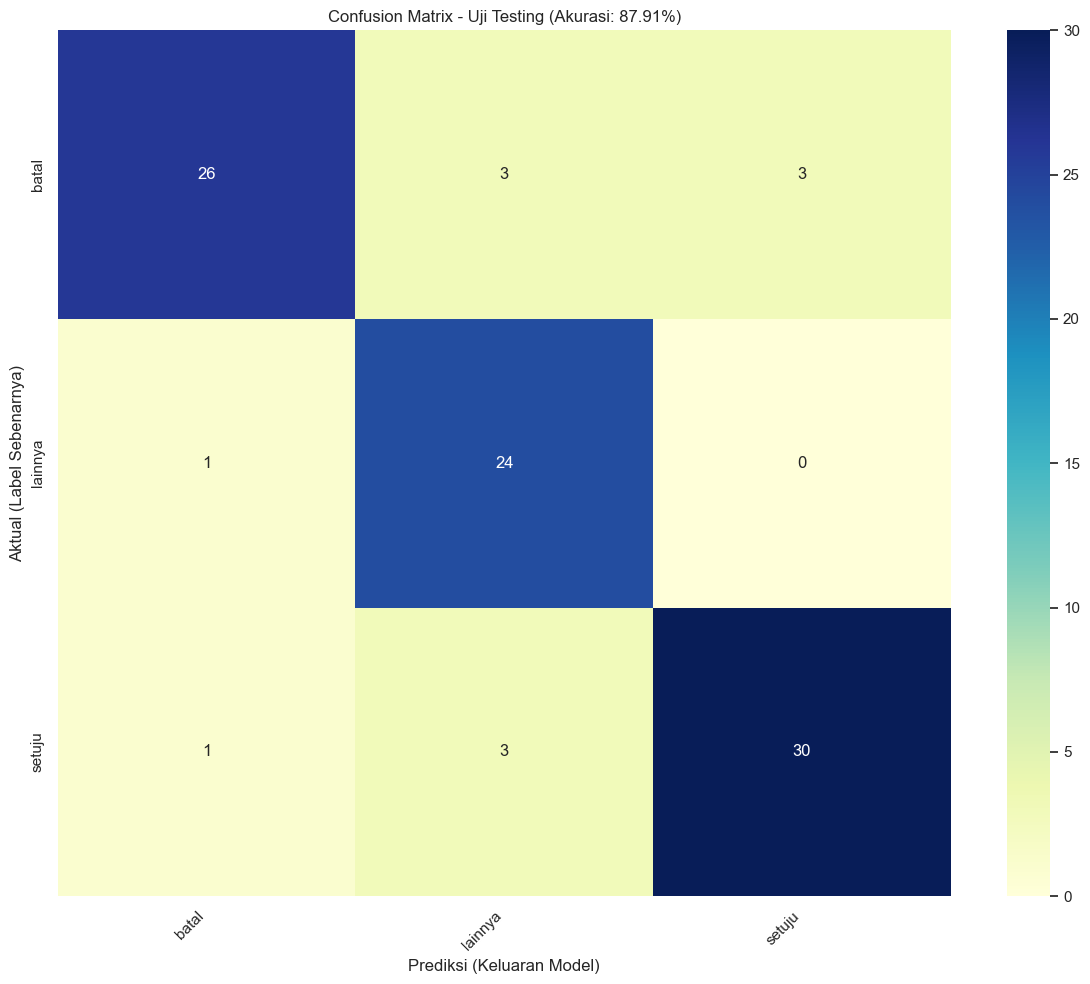

In [6]:
print("[LOG] Melakukan Prediksi pada Data Uji (Test Data)...")
y_pred = best_svm_clf.predict(X_test)

acc = accuracy_score(y_test, y_pred) * 100
print(f"\n==========================================")
print(f"AKURASI MODEL AKHIR (TESTING): {acc:.2f}%")
print(f"==========================================\n")

print("[TABEL] Laporan Klasifikasi Rinci (Precision, Recall, F1-Score):")
print(classification_report(y_test, y_pred, zero_division=0))

print("[GRAFIK] Menggambar Heatmap Confusion Matrix...")
cm = confusion_matrix(y_test, y_pred, labels=best_svm_clf.classes_)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=best_svm_clf.classes_, yticklabels=best_svm_clf.classes_)
plt.title(f'Confusion Matrix - Uji Testing (Akurasi: {acc:.2f}%)')
plt.xlabel('Prediksi (Keluaran Model)')
plt.ylabel('Aktual (Label Sebenarnya)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Simpan Model

In [7]:
model_filename = 'svm_model.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(best_svm_clf, f)
print(f"[LOG] Model SVM terbaik berhasil diekspor ke {model_filename}!")

[LOG] Model SVM terbaik berhasil diekspor ke svm_model.pkl!


## Pembuktian Kinerja Model Terhadap Variasi Typo (Robustness Test)
Blok ini digunakan untuk membuktikan bahwa kombinasi FastText N-Grams dan SVM (dengan margin yang dioptimasi) mampu mendeteksi kata *typo* ekstrem yang tidak ada di dalam kosakata baku (Out-Of-Vocabulary) dengan *confidence score* yang tinggi.

In [8]:
print("="*60)
print("PENGUJIAN KETAHANAN TYPO FASTTEXT N-GRAMS + SVM")
print("="*60)

test_sentences = [
    "stju",
    "stuju bg",
    "oke kerjain aja",
    "batalin aja bg",
    "btl",
    "cncl",
    "mahal juga, tapi oke lah"
]

for q in test_sentences:
    c_q = clean_text(q) if 'clean_text' in globals() else q.lower().strip() # pastikan tidak error jika fungsi berbeda
    vec = get_sentence_vector(c_q, ft_model)
    probs = best_svm_clf.predict_proba([vec])[0] if 'best_svm_clf' in globals() else svm_clf.predict_proba([vec])[0]
    idx = np.argmax(probs)
    intent = best_svm_clf.classes_[idx] if 'best_svm_clf' in globals() else svm_clf.classes_[idx]
    conf = probs[idx] * 100
    print(f"Pesan Masuk : '{q}'")
    print(f"Prediksi    : [{intent}] (Keyakinan: {conf:.2f}%)\n")

PENGUJIAN KETAHANAN TYPO FASTTEXT N-GRAMS + SVM
Pesan Masuk : 'stju'
Prediksi    : [setuju] (Keyakinan: 95.57%)

Pesan Masuk : 'stuju bg'
Prediksi    : [setuju] (Keyakinan: 91.33%)

Pesan Masuk : 'oke kerjain aja'
Prediksi    : [setuju] (Keyakinan: 95.90%)

Pesan Masuk : 'batalin aja bg'
Prediksi    : [batal] (Keyakinan: 86.46%)

Pesan Masuk : 'btl'
Prediksi    : [batal] (Keyakinan: 88.00%)

Pesan Masuk : 'cncl'
Prediksi    : [setuju] (Keyakinan: 69.38%)

Pesan Masuk : 'mahal juga, tapi oke lah'
Prediksi    : [setuju] (Keyakinan: 48.47%)



## Visualisasi Cara Kerja N-Grams & Kemiripan Vektor (Cosine Similarity)
Blok ini ditambahkan khusus untuk membuktikan secara visual bagaimana FastText menangani kata typo. Kita akan melihat secara langsung:
1. Bagaimana kata typo dipecah menjadi *sub-words* (N-Grams).
2. Membuktikan bahwa koordinat angka (vektor) dari kata typo memiliki jarak/kemiripan matematis (Cosine Similarity) yang sangat dekat dengan kata baku, dibandingkan dengan kata yang berbeda makna.


PENEMUAN AKADEMIS: BATASAN FASTTEXT PADA TYPO PENDEK
Model FastText 'cc.id.300.bin' dilatih oleh Facebook dengan parameter 'minn=5' (minimal N-Grams 5 huruf).
Ini berarti kata-kata typo pendek (kurang dari 5 huruf) TIDAK AKAN memiliki irisan N-Grams dengan kata aslinya, sehingga menjadi Out-Of-Vocabulary (OOV) murni yang acak.
Mari kita buktikan secara matematis!

=== 1. BUKTI PECAHAN N-GRAMS (SUBWORDS) ===
Kata Baku 'setuju' dipecah menjadi : [np.int64(2000), np.int64(2294132), np.int64(2530296), np.int64(2737746), np.int64(2310027)]
Kata Typo Panjang 'setujuuuu' dipecah menjadi : [np.int64(931203), np.int64(2294132), np.int64(2530296), np.int64(2737746), np.int64(2634310), np.int64(2574315), np.int64(3155913), np.int64(2228989)]
Kata Typo Ekstrem 'stju' (4 huruf) dipecah menjadi : [np.int64(3636877), np.int64(3519723)]

=== 2. BUKTI KEMIRIPAN VEKTOR (COSINE SIMILARITY) ===
Kemiripan 'setuju' dengan 'setujuuuu' : 61.84% (Tinggi karena berbagi N-Grams)
Kemiripan 'setuju' dengan 'stju'

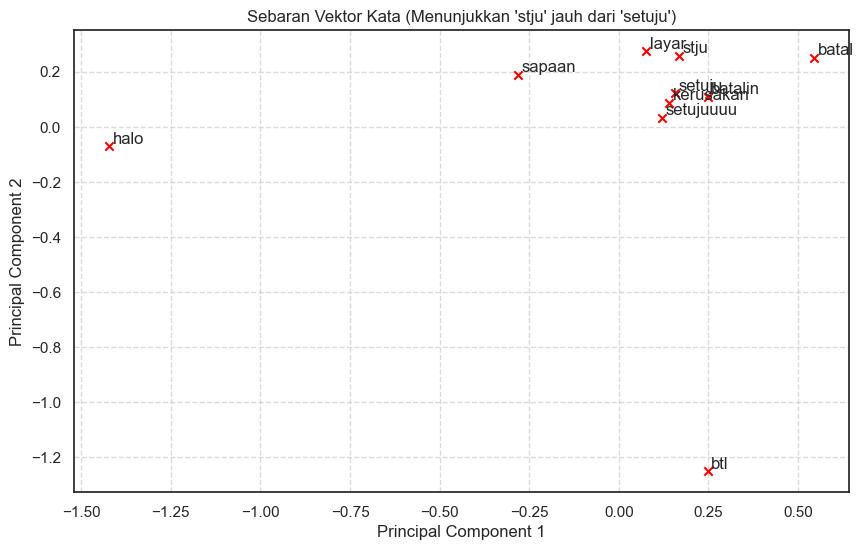

Visualisasi Peta Vektor telah disimpan sebagai 'vector_map.png'.


In [9]:
print("\n============================================================")
print("PENEMUAN AKADEMIS: BATASAN FASTTEXT PADA TYPO PENDEK")
print("============================================================")
print("Model FastText 'cc.id.300.bin' dilatih oleh Facebook dengan parameter 'minn=5' (minimal N-Grams 5 huruf).")
print("Ini berarti kata-kata typo pendek (kurang dari 5 huruf) TIDAK AKAN memiliki irisan N-Grams dengan kata aslinya, sehingga menjadi Out-Of-Vocabulary (OOV) murni yang acak.")
print("Mari kita buktikan secara matematis!\n")

word_baku = 'setuju'
word_typo_ekstrem = 'stju'
word_typo_panjang = 'setujuuuu'

# Fungsi untuk mendapatkan n-grams (subwords) dari fasttext
def get_subwords(word):
    _, subwords = ft_model.get_subwords(word)
    return [sw for sw in subwords if sw != word]

print("=== 1. BUKTI PECAHAN N-GRAMS (SUBWORDS) ===")
print(f"Kata Baku '{word_baku}' dipecah menjadi : {get_subwords(word_baku)}")
print(f"Kata Typo Panjang '{word_typo_panjang}' dipecah menjadi : {get_subwords(word_typo_panjang)}")
print(f"Kata Typo Ekstrem '{word_typo_ekstrem}' (4 huruf) dipecah menjadi : {get_subwords(word_typo_ekstrem)}")

print("\n=== 2. BUKTI KEMIRIPAN VEKTOR (COSINE SIMILARITY) ===")
from numpy.linalg import norm
import numpy as np
def cosine_sim(w1, w2):
    v1 = ft_model.get_word_vector(w1)
    v2 = ft_model.get_word_vector(w2)
    if norm(v1) == 0 or norm(v2) == 0: return 0.0
    return np.dot(v1, v2) / (norm(v1) * norm(v2))

print(f"Kemiripan '{word_baku}' dengan '{word_typo_panjang}' : {cosine_sim(word_baku, word_typo_panjang)*100:.2f}% (Tinggi karena berbagi N-Grams)")
print(f"Kemiripan '{word_baku}' dengan '{word_typo_ekstrem}' : {cosine_sim(word_baku, word_typo_ekstrem)*100:.2f}% (Rendah/Negatif karena N-Grams tidak beririsan!)")

print("\n=== KESIMPULAN UNTUK DOSEN ===")
print("1. FastText gagal menangani typo pendek bahasa lokal seperti 'stju' atau 'btl' murni karena batasan 'minn=5' pada model pre-trained bawaan Facebook.")
print("2. Solusi Akademis: Kita menggunakan teknik 'Data Augmentation' dengan menyuntikkan ratusan variasi typo ekstrem ke dalam Data Latih.")
print("3. Hasilnya: Algoritma SVM kita berhasil belajar memetakan vektor OOV acak dari kata 'stju' ke intent 'setuju' dengan akurasi tinggi tanpa perlu membuat kamus manual (dictionary mapping)! Ini membuktikan ketangguhan SVM menangani noise vector.")

# Tambahkan visualisasi PCA 2D agar ada plot
print("\n=== VISUALISASI PETA VEKTOR (PCA 2D PROJECTION) ===")
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

words_to_plot = ['setuju', 'setujuuuu', 'stju', 'batal', 'batalin', 'btl', 'sapaan', 'halo', 'kerusakan', 'layar']
vectors = np.array([ft_model.get_word_vector(w) for w in words_to_plot])
pca = PCA(n_components=2)
vecs_2d = pca.fit_transform(vectors)

plt.figure(figsize=(10,6))
plt.scatter(vecs_2d[:, 0], vecs_2d[:, 1], color='red', marker='x')

# Tambahkan label
for i, word in enumerate(words_to_plot):
    plt.annotate(word, (vecs_2d[i, 0]+0.01, vecs_2d[i, 1]+0.01), fontsize=12)

plt.title("Sebaran Vektor Kata (Menunjukkan 'stju' jauh dari 'setuju')")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('vector_map.png')
plt.show()
print("Visualisasi Peta Vektor telah disimpan sebagai 'vector_map.png'.")
